In [1]:
import pandas as pd

Introduction About the Data : The dataset The goal is to predict price of given diamond (Regression Analysis).

There are 10 independent variables (including id):

id : unique identifier of each diamond

carat : Carat (ct.) refers to the unique unit of weight measurement used exclusively to weigh gemstones and diamonds.

cut : Quality of Diamond Cut

color : Color of Diamond

clarity : Diamond clarity is a measure of the purity and rarity of the stone, graded by the visibility of these characteristics under 10-power magnification.

depth : The depth of diamond is its height (in millimeters) measured from the culet (bottom tip) to the table (flat, top surface)

table : A diamond's table is the facet which can be seen when the stone is viewed face up.

x : Diamond X dimension

y : Diamond Y dimension

x : Diamond Z dimension

Target variable:

price: Price of the given Diamond.

In [14]:
data = pd.read_csv(
    r"C:\Users\obaid\OneDrive\Desktop\Gimston_Datset\train.csv"
)

In [15]:
data.head(2)

,id,carat,cut,color,clarity,depth,table,x,y,z,price
0,0,1.52,Premium,F,VS2,62.2,58.0,7.27,7.33,4.55,13619
1,1,2.03,Very Good,J,SI2,62.0,58.0,8.06,8.12,5.05,13387


In [16]:
data["color"].value_counts()

color
G    44391
E    35869
F    34258
H    30799
D    24286
I    17514
J     6456
Name: count, dtype: int64

In [17]:
data.sample(10)

,id,carat,cut,color,clarity,depth,table,x,y,z,price
157879,157879,0.30,Ideal,E,VS2,61.2,56.0,4.39,4.41,2.69,844
87494,87494,0.33,Ideal,F,VVS2,60.9,56.0,4.50,4.52,2.75,945
158042,158042,0.30,Premium,G,VVS2,62.9,58.0,4.31,4.26,2.69,878
14425,14425,0.40,Premium,E,VS2,61.3,59.0,4.70,4.73,2.90,781
12419,12419,0.41,Very Good,E,SI1,63.6,58.0,4.71,4.74,3.01,755
159430,159430,1.02,Very Good,I,VS2,63.4,58.0,6.43,6.39,4.07,3265
74712,74712,0.70,Good,D,VS1,63.8,59.0,5.64,5.59,3.58,3180
73496,73496,0.54,Ideal,E,VS2,62.0,57.0,5.24,5.21,3.25,1642
174137,174137,0.42,Premium,F,VS1,61.2,59.0,4.82,4.85,2.96,1154
30422,30422,1.02,Ideal,G,VS1,62.3,56.0,6.44,6.40,4.00,7553


In [18]:
data.isnull().sum()

id         0
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
x          0
y          0
z          0
price      0
dtype: int64

In [19]:
data.size

2129303

In [20]:
data.shape

(193573, 11)

In [21]:

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 193573 entries, 0 to 193572
Data columns (total 11 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       193573 non-null  int64  
 1   carat    193573 non-null  float64
 2   cut      193573 non-null  str    
 3   color    193573 non-null  str    
 4   clarity  193573 non-null  str    
 5   depth    193573 non-null  float64
 6   table    193573 non-null  float64
 7   x        193573 non-null  float64
 8   y        193573 non-null  float64
 9   z        193573 non-null  float64
 10  price    193573 non-null  int64  
dtypes: float64(6), int64(2), str(3)
memory usage: 16.2 MB


In [22]:
data.columns

Index(['id', 'carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y',
       'z', 'price'],
      dtype='str')

In [23]:

data.drop(labels=["id"],axis=1,inplace=True)

In [24]:
data

,carat,cut,color,clarity,depth,table,x,y,z,price
0,1.52,Premium,F,VS2,62.2,58.0,7.27,7.33,4.55,13619
1,2.03,Very Good,J,SI2,62.0,58.0,8.06,8.12,5.05,13387
2,0.70,Ideal,G,VS1,61.2,57.0,5.69,5.73,3.50,2772
3,0.32,Ideal,G,VS1,61.6,56.0,4.38,4.41,2.71,666
4,1.70,Premium,G,VS2,62.6,59.0,7.65,7.61,4.77,14453
...,...,...,...,...,...,...,...,...,...,...
193568,0.31,Ideal,D,VVS2,61.1,56.0,4.35,4.39,2.67,1130
193569,0.70,Premium,G,VVS2,60.3,58.0,5.75,5.77,3.47,2874
193570,0.73,Very Good,F,SI1,63.1,57.0,5.72,5.75,3.62,3036
193571,0.34,Very Good,D,SI1,62.9,55.0,4.45,4.49,2.81,681


In [25]:
data.duplicated().sum()

np.int64(0)

In [26]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 193573 entries, 0 to 193572
Data columns (total 10 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   carat    193573 non-null  float64
 1   cut      193573 non-null  str    
 2   color    193573 non-null  str    
 3   clarity  193573 non-null  str    
 4   depth    193573 non-null  float64
 5   table    193573 non-null  float64
 6   x        193573 non-null  float64
 7   y        193573 non-null  float64
 8   z        193573 non-null  float64
 9   price    193573 non-null  int64  
dtypes: float64(6), int64(1), str(3)
memory usage: 14.8 MB


In [27]:
cat_columns=data.columns[data.dtypes=="object"]

In [28]:

num_columns=data.columns[data.dtypes!="object"]

In [29]:
data[num_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
carat,193573.0,0.790688,0.462688,0.2,0.40,0.70,1.03,3.50
depth,193573.0,61.820574,1.081704,52.1,61.30,61.90,62.40,71.60
table,193573.0,57.227675,1.918844,49.0,56.00,57.00,58.00,79.00
x,193573.0,5.715312,1.109422,0.0,4.70,5.70,6.51,9.65
y,193573.0,5.720094,1.102333,0.0,4.71,5.72,6.51,10.01
z,193573.0,3.534246,0.688922,0.0,2.90,3.53,4.03,31.30
price,193573.0,3969.155414,4034.374138,326.0,951.00,2401.00,5408.00,18818.00


In [30]:
data[cat_columns]

""
0
1
2
3
4
...
193568
193569
193570
193571


In [31]:

for col in cat_columns:
    print(data[col].value_counts())
    print(f"here is the total count:{len(data[col].value_counts())}")
    print("=======================")

In [32]:
data[num_columns]

,carat,cut,color,clarity,depth,table,x,y,z,price
0,1.52,Premium,F,VS2,62.2,58.0,7.27,7.33,4.55,13619
1,2.03,Very Good,J,SI2,62.0,58.0,8.06,8.12,5.05,13387
2,0.70,Ideal,G,VS1,61.2,57.0,5.69,5.73,3.50,2772
3,0.32,Ideal,G,VS1,61.6,56.0,4.38,4.41,2.71,666
4,1.70,Premium,G,VS2,62.6,59.0,7.65,7.61,4.77,14453
...,...,...,...,...,...,...,...,...,...,...
193568,0.31,Ideal,D,VVS2,61.1,56.0,4.35,4.39,2.67,1130
193569,0.70,Premium,G,VVS2,60.3,58.0,5.75,5.77,3.47,2874
193570,0.73,Very Good,F,SI1,63.1,57.0,5.72,5.75,3.62,3036
193571,0.34,Very Good,D,SI1,62.9,55.0,4.45,4.49,2.81,681


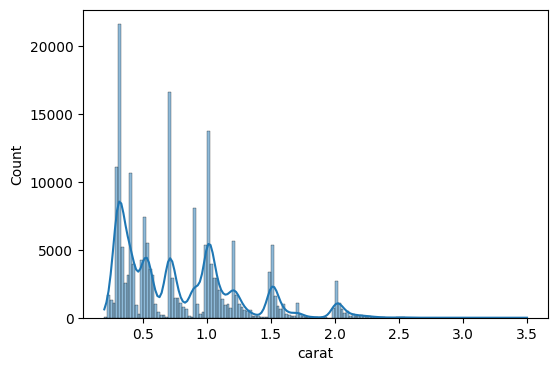

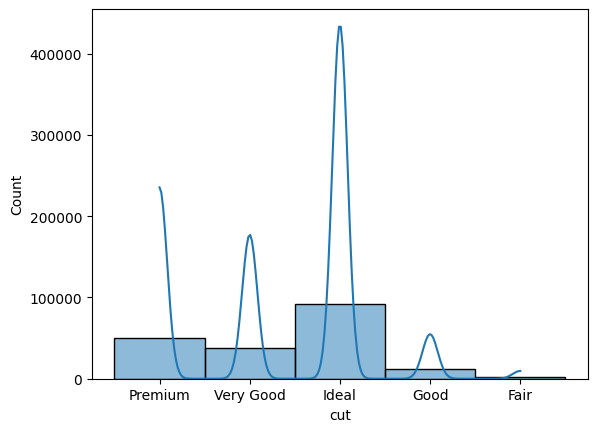

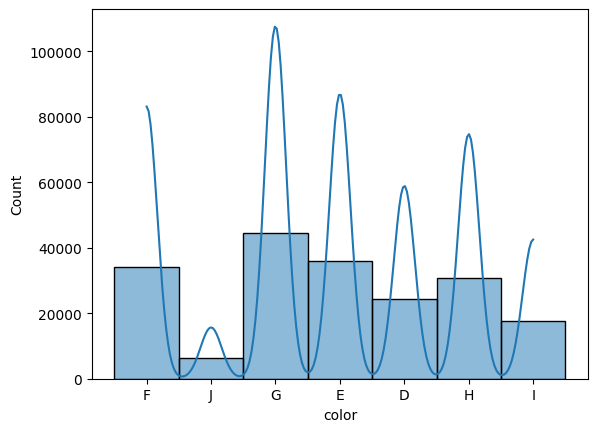

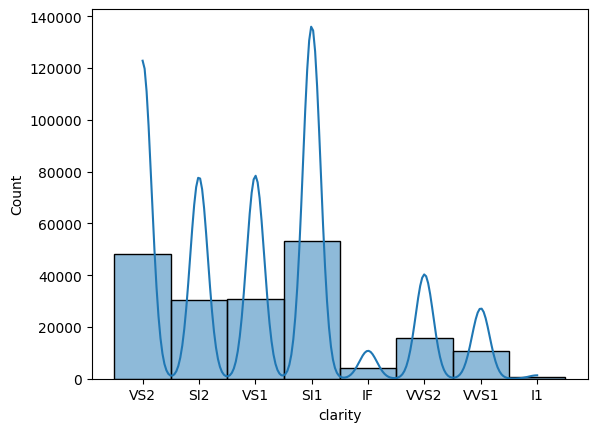

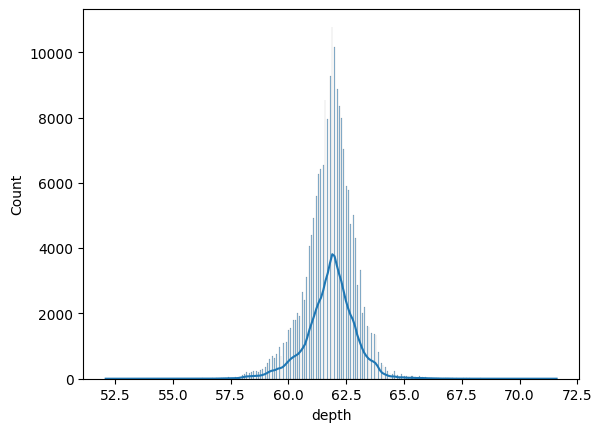

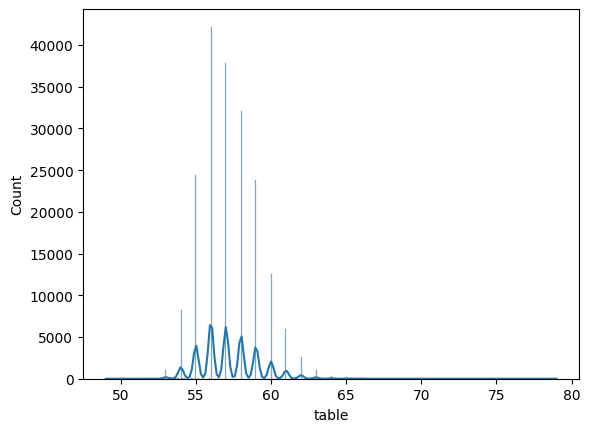

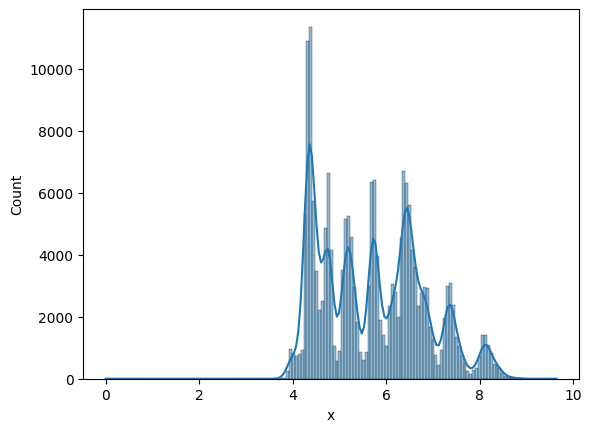

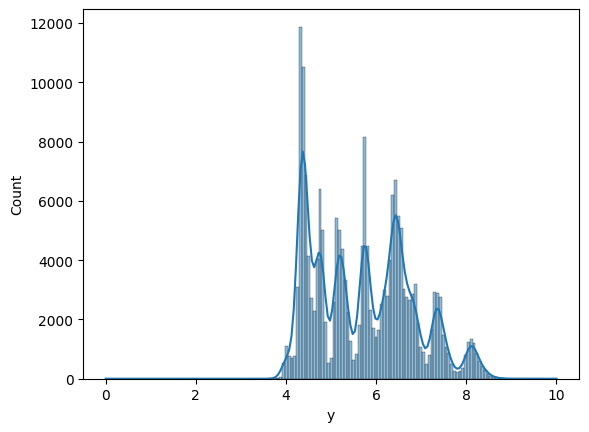

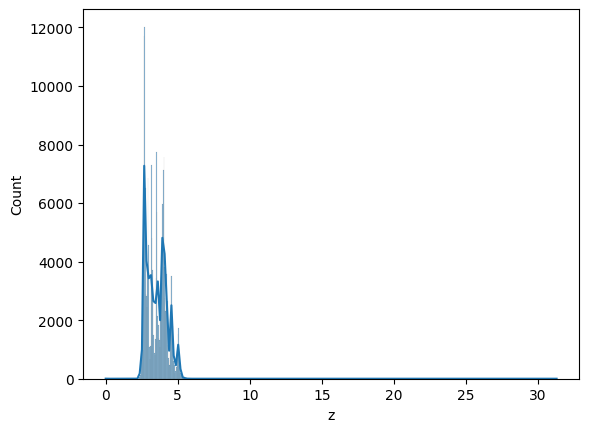

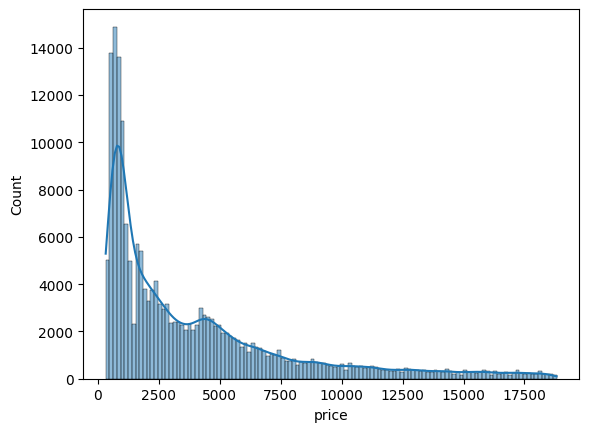

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))

for col in num_columns:
    sns.histplot(data=data,x=col,kde=True)
    print("\n")
    plt.show()

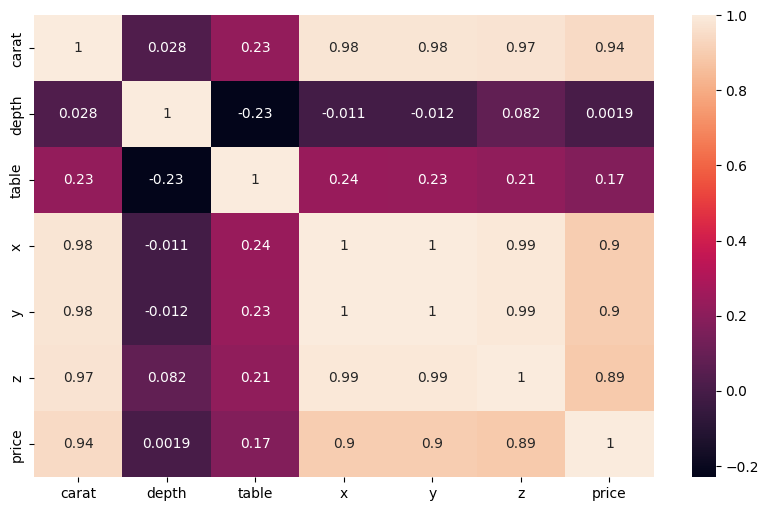

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_data = data.select_dtypes(include="number")

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_data.corr(), annot=True)
plt.show()

In [36]:
data[cat_columns]

""
0
1
2
3
4
...
193568
193569
193570
193571


In [37]:
# it is a oridinal encoding
cut_map={"Fair":1,"Good":2,"Very Good":3,"Premium":4,"Ideal":5}
clarity_map = {"I1":1,"SI2":2 ,"SI1":3 ,"VS2":4 , "VS1":5 , "VVS2":6 , "VVS1":7 ,"IF":8}
color_map = {"D":1 ,"E":2 ,"F":3 , "G":4 ,"H":5 , "I":6, "J":7}

In [38]:
data["cut"]=data["cut"].map(cut_map)
data["clarity"]=data["clarity"].map(clarity_map)
data["color"]=data["color"].map(color_map)

In [39]:
data


,carat,cut,color,clarity,depth,table,x,y,z,price
0,1.52,4,3,4,62.2,58.0,7.27,7.33,4.55,13619
1,2.03,3,7,2,62.0,58.0,8.06,8.12,5.05,13387
2,0.70,5,4,5,61.2,57.0,5.69,5.73,3.50,2772
3,0.32,5,4,5,61.6,56.0,4.38,4.41,2.71,666
4,1.70,4,4,4,62.6,59.0,7.65,7.61,4.77,14453
...,...,...,...,...,...,...,...,...,...,...
193568,0.31,5,1,6,61.1,56.0,4.35,4.39,2.67,1130
193569,0.70,4,4,6,60.3,58.0,5.75,5.77,3.47,2874
193570,0.73,3,3,3,63.1,57.0,5.72,5.75,3.62,3036
193571,0.34,3,1,3,62.9,55.0,4.45,4.49,2.81,681


In [41]:
from sklearn.impute import SimpleImputer ## HAndling Missing Values
from sklearn.preprocessing import StandardScaler # HAndling Feature Scaling
from sklearn.preprocessing import OrdinalEncoder # Ordinal Encoding
## pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [42]:
data.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z',
       'price'],
      dtype='str')

In [44]:
X = data.drop(labels=["price"], axis=1)
y = data["price"]

In [46]:
X


,carat,cut,color,clarity,depth,table,x,y,z
0,1.52,4,3,4,62.2,58.0,7.27,7.33,4.55
1,2.03,3,7,2,62.0,58.0,8.06,8.12,5.05
2,0.70,5,4,5,61.2,57.0,5.69,5.73,3.50
3,0.32,5,4,5,61.6,56.0,4.38,4.41,2.71
4,1.70,4,4,4,62.6,59.0,7.65,7.61,4.77
...,...,...,...,...,...,...,...,...,...
193568,0.31,5,1,6,61.1,56.0,4.35,4.39,2.67
193569,0.70,4,4,6,60.3,58.0,5.75,5.77,3.47
193570,0.73,3,3,3,63.1,57.0,5.72,5.75,3.62
193571,0.34,3,1,3,62.9,55.0,4.45,4.49,2.81


In [47]:
y

0         13619
1         13387
2          2772
3           666
4         14453
          ...  
193568     1130
193569     2874
193570     3036
193571      681
193572     2258
Name: price, Length: 193573, dtype: int64

In [48]:

X.info()

<class 'pandas.DataFrame'>
RangeIndex: 193573 entries, 0 to 193572
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   carat    193573 non-null  float64
 1   cut      193573 non-null  int64  
 2   color    193573 non-null  int64  
 3   clarity  193573 non-null  int64  
 4   depth    193573 non-null  float64
 5   table    193573 non-null  float64
 6   x        193573 non-null  float64
 7   y        193573 non-null  float64
 8   z        193573 non-null  float64
dtypes: float64(6), int64(3)
memory usage: 13.3 MB


In [49]:
X.select_dtypes(include="object")

""
0
1
2
3
4
...
193568
193569
193570
193571


In [50]:
X.select_dtypes(exclude="object")

,carat,cut,color,clarity,depth,table,x,y,z
0,1.52,4,3,4,62.2,58.0,7.27,7.33,4.55
1,2.03,3,7,2,62.0,58.0,8.06,8.12,5.05
2,0.70,5,4,5,61.2,57.0,5.69,5.73,3.50
3,0.32,5,4,5,61.6,56.0,4.38,4.41,2.71
4,1.70,4,4,4,62.6,59.0,7.65,7.61,4.77
...,...,...,...,...,...,...,...,...,...
193568,0.31,5,1,6,61.1,56.0,4.35,4.39,2.67
193569,0.70,4,4,6,60.3,58.0,5.75,5.77,3.47
193570,0.73,3,3,3,63.1,57.0,5.72,5.75,3.62
193571,0.34,3,1,3,62.9,55.0,4.45,4.49,2.81


In [51]:
cat_cols=X.select_dtypes(include="object").columns

num_cols=X.select_dtypes(exclude="object").columns

In [52]:
cat_cols

Index([], dtype='str')

In [53]:
num_cols

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z'], dtype='str')

In [54]:
X.select_dtypes(include="object").head()

""
0
1
2
3
4


In [55]:

X["clarity"].value_counts()

clarity
3    53272
4    48027
5    30669
2    30484
6    15762
7    10628
8     4219
1      512
Name: count, dtype: int64

In [56]:
cut_categories = ['Fair', 'Good', 'Very Good','Premium','Ideal']
color_categories = ['D', 'E', 'F', 'G', 'H', 'I', 'J']
clarity_categories = ['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF']

In [57]:

num_pipeline=Pipeline(
    steps=[
        ("imputer",SimpleImputer()),
        ("scaler",StandardScaler())
    ]
)

In [58]:

cat_pipeline=Pipeline(

    steps=[
        ("imputer",SimpleImputer(strategy="most_frequent")),
        ("ordinalencoder",OrdinalEncoder(categories=[cut_categories,color_categories,clarity_categories]))

    ]
)

In [59]:

num_cols

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z'], dtype='str')

In [60]:

cat_cols

Index([], dtype='str')

In [61]:
preprocessor=ColumnTransformer(

    [
        ("num_pipeline",num_pipeline,num_cols),
        ("cat_pipeline",cat_pipeline,cat_cols)
    ]
)

In [62]:
X

,carat,cut,color,clarity,depth,table,x,y,z
0,1.52,4,3,4,62.2,58.0,7.27,7.33,4.55
1,2.03,3,7,2,62.0,58.0,8.06,8.12,5.05
2,0.70,5,4,5,61.2,57.0,5.69,5.73,3.50
3,0.32,5,4,5,61.6,56.0,4.38,4.41,2.71
4,1.70,4,4,4,62.6,59.0,7.65,7.61,4.77
...,...,...,...,...,...,...,...,...,...
193568,0.31,5,1,6,61.1,56.0,4.35,4.39,2.67
193569,0.70,4,4,6,60.3,58.0,5.75,5.77,3.47
193570,0.73,3,3,3,63.1,57.0,5.72,5.75,3.62
193571,0.34,3,1,3,62.9,55.0,4.45,4.49,2.81


In [63]:
y

0         13619
1         13387
2          2772
3           666
4         14453
          ...  
193568     1130
193569     2874
193570     3036
193571      681
193572     2258
Name: price, Length: 193573, dtype: int64

In [64]:

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30, random_state=42)

In [65]:

X_test.shape

(58072, 9)

In [66]:

y_train.head()

11504      1181
95284      7418
184777    12755
5419       1020
45466       445
Name: price, dtype: int64

In [67]:
preprocessor.fit_transform(X_train)

array([[-0.82314374,  0.87410007, -0.93674681, ..., -0.78045073,
        -0.83510329, -0.87602377],
       [ 0.94502267, -1.13764403,  0.91085333, ...,  1.07322572,
         1.16638856,  0.94663261],
       [ 1.9584839 , -0.13177198,  0.91085333, ...,  1.70311578,
         1.75506264,  1.74223659],
       ...,
       [ 0.92345966, -0.13177198,  0.29498662, ...,  0.99223986,
         0.92186241,  1.0478913 ],
       [-1.03877378, -1.13764403,  0.29498662, ..., -1.21237535,
        -1.19736425, -1.25212747],
       [-1.03877378, -1.13764403,  0.29498662, ..., -1.23937063,
        -1.2154773 , -1.20873089]], shape=(135501, 9))

In [68]:

preprocessor.transform(X_test)

array([[-0.62907669,  0.87410007, -1.55261352, ..., -0.60048215,
        -0.58152061, -0.57224771],
       [ 2.60537405, -1.13764403,  0.29498662, ...,  2.12604196,
         2.19883232,  1.9592195 ],
       [-1.1250258 , -0.13177198, -0.93674681, ..., -1.37434708,
        -1.41472084, -1.46911037],
       ...,
       [-0.82314374,  0.87410007,  0.29498662, ..., -0.83444131,
        -0.86227286, -0.84709272],
       [ 0.90189666, -0.13177198,  1.52672004, ...,  1.04623044,
         0.96714503,  0.93216709],
       [ 0.47063656, -1.13764403, -0.93674681, ...,  0.55131682,
         0.66827973,  0.70071866]], shape=(58072, 9))

In [69]:

preprocessor.get_feature_names_out()

array(['num_pipeline__carat', 'num_pipeline__cut', 'num_pipeline__color',
       'num_pipeline__clarity', 'num_pipeline__depth',
       'num_pipeline__table', 'num_pipeline__x', 'num_pipeline__y',
       'num_pipeline__z'], dtype=object)

In [70]:
X_train=pd.DataFrame(preprocessor.fit_transform(X_train),columns=preprocessor.get_feature_names_out())
X_test=pd.DataFrame(preprocessor.transform(X_test),columns=preprocessor.get_feature_names_out())

In [71]:

X_train

,num_pipeline__carat,num_pipeline__cut,num_pipeline__color,num_pipeline__clarity,num_pipeline__depth,num_pipeline__table,num_pipeline__x,num_pipeline__y,num_pipeline__z
0,-0.823144,0.874100,-0.936747,1.350746,-1.129988,-0.641897,-0.780451,-0.835103,-0.876024
1,0.945023,-1.137644,0.910853,0.684455,-1.777823,0.921902,1.073226,1.166389,0.946633
2,1.958484,-0.131772,0.910853,0.018164,0.165682,0.400636,1.703116,1.755063,1.742237
3,-0.995648,0.874100,-0.320880,2.017037,-0.574701,-0.641897,-1.122391,-1.161138,-1.165334
4,-0.995648,-1.137644,1.526720,-0.648127,0.258230,0.400636,-1.176382,-1.152082,-1.136403
...,...,...,...,...,...,...,...,...,...
135496,-0.629077,-1.137644,-0.936747,-0.648127,-1.500179,1.964434,-0.546492,-0.518125,-0.644575
135497,2.411307,-1.137644,-0.320880,-0.648127,0.443325,2.485700,1.919078,1.872797,1.930288
135498,0.923460,-0.131772,0.294987,0.018164,0.906065,0.400636,0.992240,0.921862,1.047891
135499,-1.038774,-1.137644,0.294987,2.017037,-0.667249,-0.641897,-1.212375,-1.197364,-1.252127


In [72]:
X_test

,num_pipeline__carat,num_pipeline__cut,num_pipeline__color,num_pipeline__clarity,num_pipeline__depth,num_pipeline__table,num_pipeline__x,num_pipeline__y,num_pipeline__z
0,-0.629077,0.874100,-1.552614,-0.648127,0.258230,-0.120630,-0.600482,-0.581521,-0.572248
1,2.605374,-1.137644,0.294987,-1.314417,-2.148014,-0.120630,2.126042,2.198832,1.959219
2,-1.125026,-0.131772,-0.936747,2.017037,-1.222536,0.921902,-1.374347,-1.414721,-1.469110
3,-1.017211,-0.131772,1.526720,2.017037,-0.574701,0.921902,-1.158385,-1.161138,-1.194265
4,0.858771,0.874100,0.910853,-0.648127,0.628421,-0.641897,0.947248,0.985258,1.004495
...,...,...,...,...,...,...,...,...,...
58067,0.255007,-1.137644,1.526720,-1.314417,0.535873,0.921902,0.416340,0.369414,0.425874
58068,-0.607514,0.874100,-1.552614,0.018164,0.535873,-0.641897,-0.528495,-0.554351,-0.499920
58069,-0.823144,0.874100,0.294987,2.017037,-0.019414,-0.641897,-0.834441,-0.862273,-0.847093
58070,0.901897,-0.131772,1.526720,-0.648127,-0.667249,1.443168,1.046230,0.967145,0.932167



model training